# Project Python Foundations: FoodHub Data Analysis

### Context

The number of restaurants in New York is increasing day by day. Lots of students and busy professionals rely on those restaurants due to their hectic lifestyles. Online food delivery service is a great option for them. It provides them with good food from their favorite restaurants. A food aggregator company FoodHub offers access to multiple restaurants through a single smartphone app.

The app allows the restaurants to receive a direct online order from a customer. The app assigns a delivery person from the company to pick up the order after it is confirmed by the restaurant. The delivery person then uses the map to reach the restaurant and waits for the food package. Once the food package is handed over to the delivery person, he/she confirms the pick-up in the app and travels to the customer's location to deliver the food. The delivery person confirms the drop-off in the app after delivering the food package to the customer. The customer can rate the order in the app. The food aggregator earns money by collecting a fixed margin of the delivery order from the restaurants.

### Objective

The food aggregator company has stored the data of the different orders made by the registered customers in their online portal. They want to analyze the data to get a fair idea about the demand of different restaurants which will help them in enhancing their customer experience. Suppose you are hired as a Data Scientist in this company and the Data Science team has shared some of the key questions that need to be answered. Perform the data analysis to find answers to these questions that will help the company to improve the business.

### Data Description

The data contains the different data related to a food order. The detailed data dictionary is given below.

### Data Dictionary

* order_id: Unique ID of the order
* customer_id: ID of the customer who ordered the food
* restaurant_name: Name of the restaurant
* cuisine_type: Cuisine ordered by the customer
* cost_of_the_order: Cost of the order
* day_of_the_week: Indicates whether the order is placed on a weekday or weekend (The weekday is from Monday to Friday and the weekend is Saturday and Sunday)
* rating: Rating given by the customer out of 5
* food_preparation_time: Time (in minutes) taken by the restaurant to prepare the food. This is calculated by taking the difference between the timestamps of the restaurant's order confirmation and the delivery person's pick-up confirmation.
* delivery_time: Time (in minutes) taken by the delivery person to deliver the food package. This is calculated by taking the difference between the timestamps of the delivery person's pick-up confirmation and drop-off information

### Let us start by importing the required libraries

In [1]:
# Installing the libraries with the specified version.
!pip install --upgrade numpy pandas matplotlib seaborn -q --user

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
numba 0.62.1 requires numpy<2.4,>=1.22, but you have numpy 2.4.4 which is incompatible.
streamlit 1.51.0 requires pandas<3,>=1.4.0, but you have pandas 3.0.2 which is incompatible.


**Note**:
- After running the above cell, kindly restart the runtime (for Google Colab) or notebook kernel (for Jupyter Notebook), and run all cells sequentially from the next cell.
- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in ***this notebook***.

In [2]:
# This code imports all the libraries for data manipulation.
import numpy as np
import pandas as pd

# This code imports all the libraries for data visualization.
import matplotlib.pyplot as plt
import seaborn as sns

### Understanding the structure of the data

In [4]:
# This code reads the data from a file that is stored locally.
df = pd.read_csv("foodhub_order.csv")

In [5]:
# This code shows the first 5 rows.
fh_df = pd.DataFrame(df) #Creates a dataframe.
fh_df.head() #This chooses the first 5 rows.

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24


### **Question 1:** How many rows and columns are present in the data? [0.5 mark]

In [6]:
# This code shows how many rows and columns are present in the data.
fh_df.shape

(1898, 9)

#### Observations:


### **Question 2:** What are the datatypes of the different columns in the dataset? (The info() function can be used) [0.5 mark]

In [7]:
# This code shows the datatypes of the different columns in the dataset.
fh_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1898 non-null   object 
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 133.6+ KB


#### Observations:


### **Question 3:** Are there any missing values in the data? If yes, treat them using an appropriate method. [1 mark]

In [8]:
# This code reveals if there are any missing values in the dataset.
missing_values = pd.isna(fh_df) #False means that the field is not null. True means that there are null values in a field.
missing_values


,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...
1893,False,False,False,False,False,False,False,False,False
1894,False,False,False,False,False,False,False,False,False
1895,False,False,False,False,False,False,False,False,False
1896,False,False,False,False,False,False,False,False,False


#### Observations:


### **Question 4:** Check the statistical summary of the data. What is the minimum, average, and maximum time it takes for food to be prepared once an order is placed? [2 marks]

In [9]:
# This code shows the minimum, average, and maximum time it takes for food to be prepared once an order is placed.
fh_df.describe()

,order_id,customer_id,cost_of_the_order,food_preparation_time,delivery_time
count,1.898000e+03,1898.000000,1898.000000,1898.000000,1898.000000
mean,1.477496e+06,171168.478398,16.498851,27.371970,24.161749
std,5.480497e+02,113698.139743,7.483812,4.632481,4.972637
min,1.476547e+06,1311.000000,4.470000,20.000000,15.000000
25%,1.477021e+06,77787.750000,12.080000,23.000000,20.000000
50%,1.477496e+06,128600.000000,14.140000,27.000000,25.000000
75%,1.477970e+06,270525.000000,22.297500,31.000000,28.000000
max,1.478444e+06,405334.000000,35.410000,35.000000,33.000000


#### Observations:


### **Question 5:** How many orders are not rated? [1 mark]

736 orders are not rated.

In [10]:
# This code shows how many orders are not rated.
not_rate = fh_df.groupby(['rating']).size()
not_rate

rating
3            188
4            386
5            588
Not given    736
dtype: int64

### Exploratory Data Analysis (EDA)

### Univariate Analysis

### **Question 6:** Explore all the variables and provide observations on their distributions. (Generally, histograms, boxplots, countplots, etc. are used for univariate exploration.) [9 marks]

c:\ProgramData\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 140 (\x8c) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\ProgramData\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 142 (\x8e) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


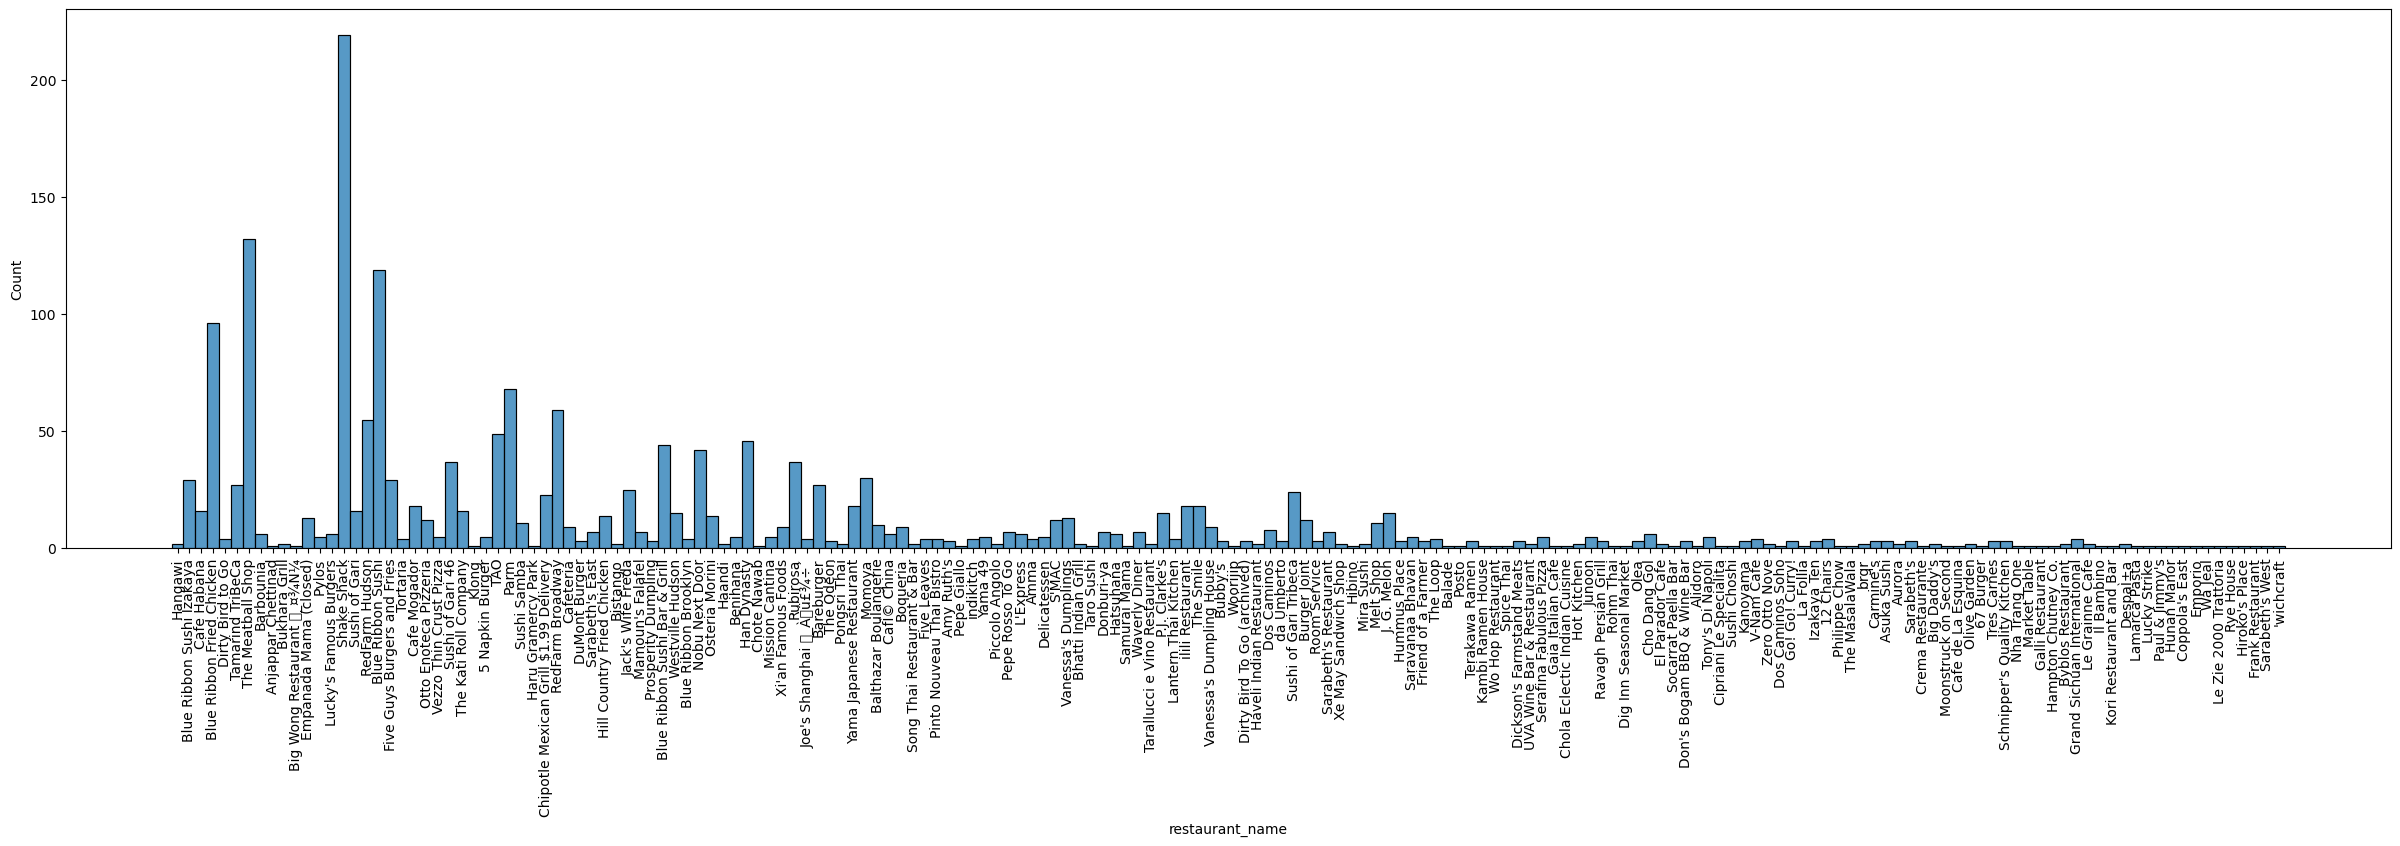

In [11]:
# Histogram - This graph shows the restaurants with the highest order counts. The data has a Positive Skew (Right Skew).  
# This means that most of the restaurant order data points are on the left.
plt.figure(figsize=(30,7))
sns.histplot(data=fh_df,x='restaurant_name')
plt.xticks(rotation=90)
plt.show()



([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37,
  38,
  39,
  40,
  41,
  42,
  43,
  44,
  45,
  46,
  47,
  48,
  49,
  50,
  51,
  52,
  53,
  54,
  55,
  56,
  57,
  58,
  59,
  60,
  61,
  62,
  63,
  64,
  65,
  66,
  67,
  68,
  69,
  70,
  71,
  72,
  73,
  74,
  75,
  76,
  77,
  78,
  79,
  80,
  81,
  82,
  83,
  84,
  85,
  86,
  87,
  88,
  89,
  90,
  91,
  92,
  93,
  94,
  95,
  96,
  97,
  98,
  99,
  100,
  101,
  102,
  103,
  104,
  105,
  106,
  107,
  108,
  109,
  110,
  111,
  112,
  113,
  114,
  115,
  116,
  117,
  118,
  119,
  120,
  121,
  122,
  123,
  124,
  125,
  126,
  127,
  128,
  129,
  130,
  131,
  132,
  133,
  134,
  135,
  136,
  137,
  138,
  139,
  140,
  141,
  142,
  143,
  144,
  145,
  146,
  147,
  148,
  149,
  150,
  151,
  152,
  153,
  154,
  155,
  156,
  157,
  15

c:\ProgramData\anaconda3\Lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 140 (\x8c) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
c:\ProgramData\anaconda3\Lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 142 (\x8e) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
c:\ProgramData\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 140 (\x8c) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\ProgramData\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 142 (\x8e) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


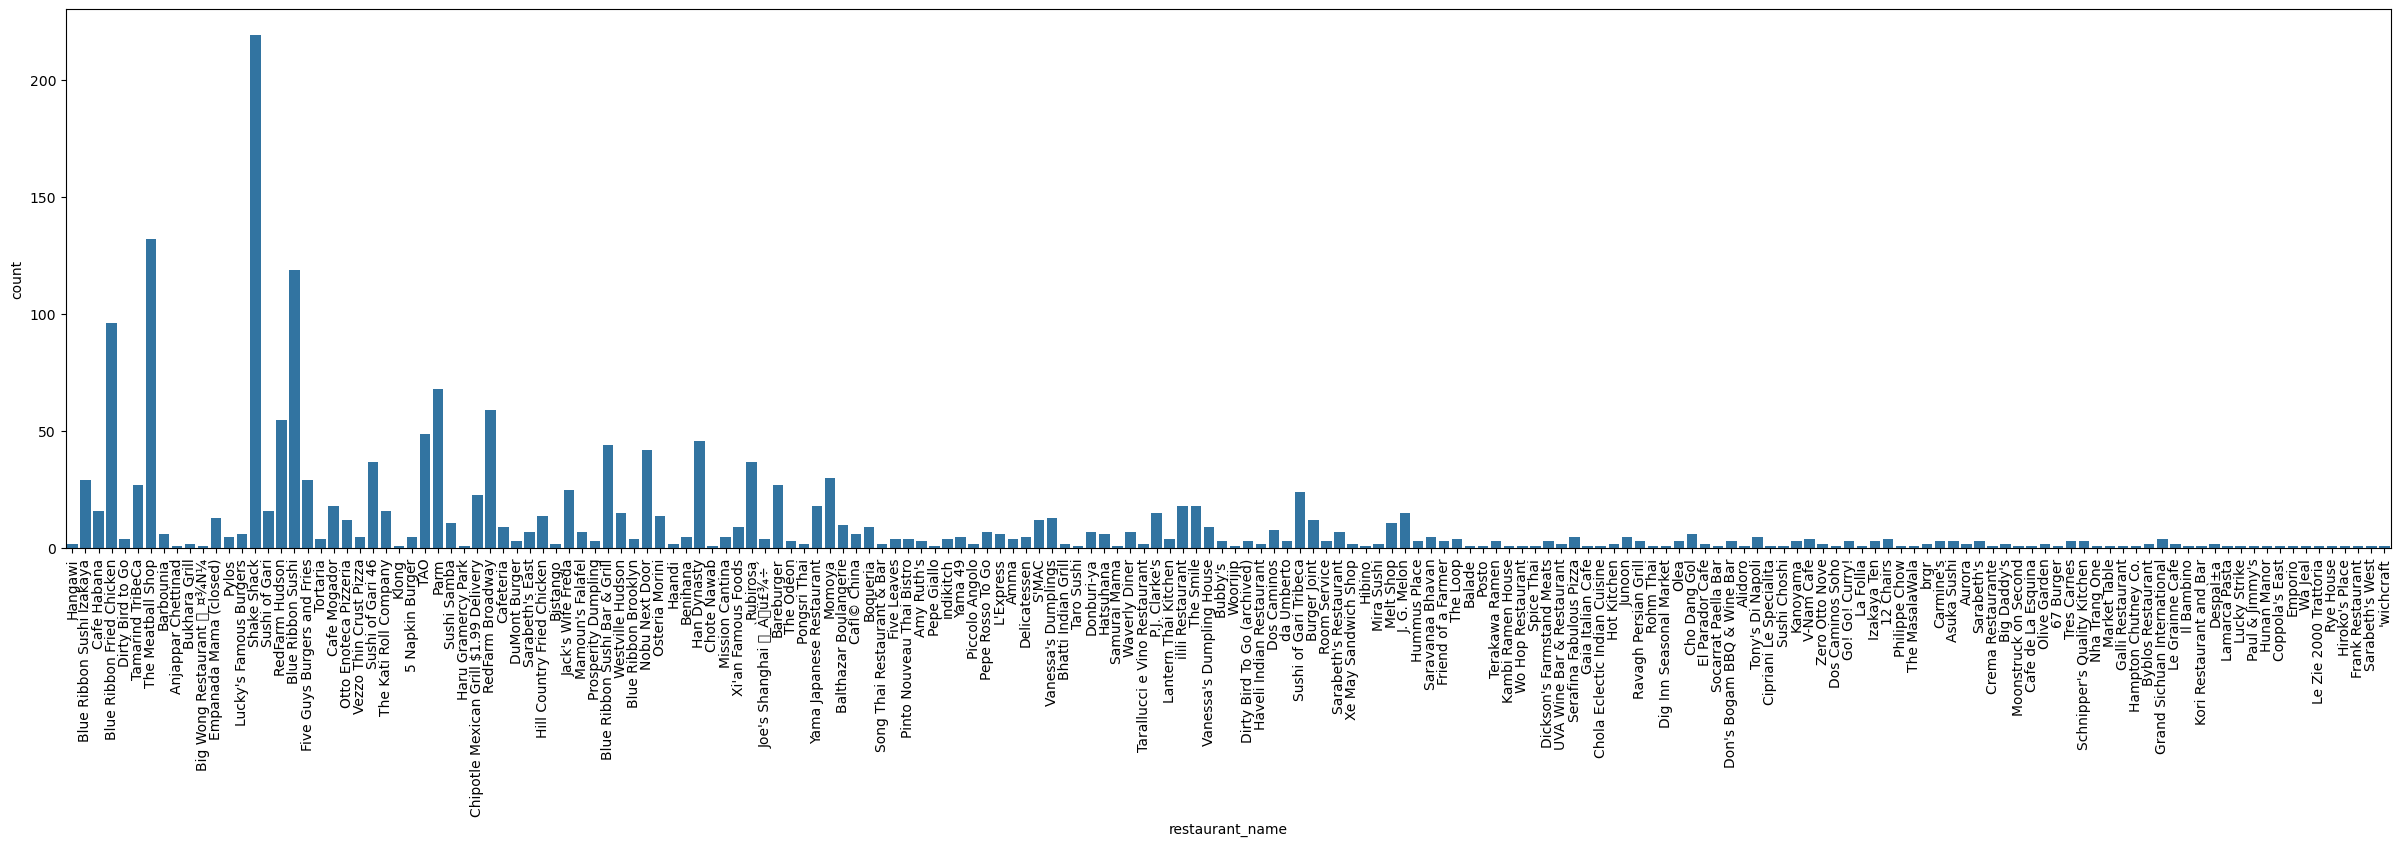

In [12]:
# Countplot - This graph shows very simliar information that the Histogram does regarding the restaurants with the highest order counts. 
# The data has a Positive Skew (Right Skew).  
# This means that most of the restaurant order data points are on the left.
plt.figure(figsize=(30,7))
sns.countplot(data=df,x='restaurant_name')
plt.xticks(rotation = 90)

c:\ProgramData\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 140 (\x8c) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\ProgramData\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 142 (\x8e) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


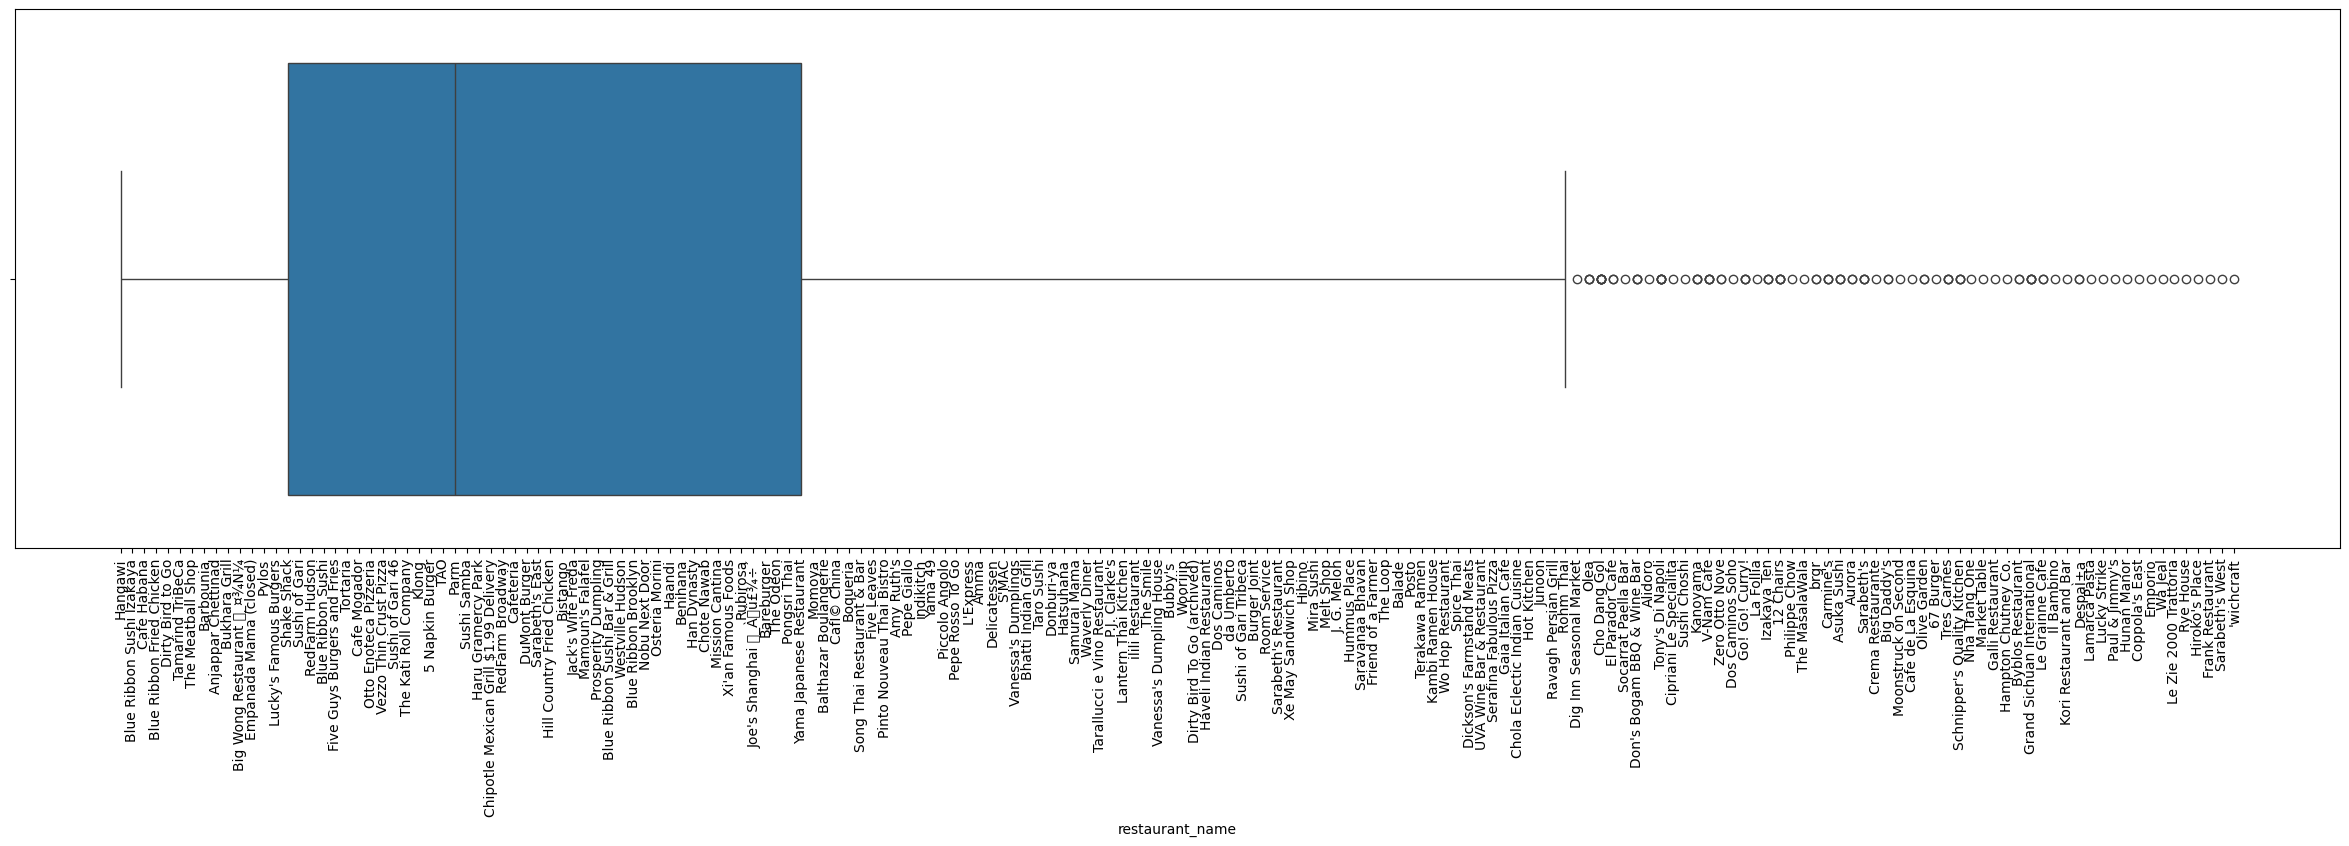

In [13]:
# Boxplot - This graph show that the data has a Positive Skew (Right Skew). 
# This explains in greater detail what the Histogram showed. 
# The right tail is longer than the left.
# This means the restauant data is on the left with a few large values pulling the distribution to the right.
# The right side of the Boxplot, shows all restaurants that are outliers.
plt.figure(figsize=(30,7))
sns.boxplot(data=fh_df,x='restaurant_name')
plt.xticks(rotation=90)
plt.show()

### **Question 7**: Which are the top 5 restaurants in terms of the number of orders received? [1 mark]

The top 5 restaurants in terms of the number of orders received are: Shake Shack, Blue Ribbon Fried Chicken, Blue Ribbon Sushi, The Meatball Shop and Parm.

In [14]:
#This code allowed the grouping of all the restaurants by restaurant_name, cuisine and counted by the order id.
Top_count = fh_df.groupby(['restaurant_name', 'cuisine_type'])['order_id'].count().reset_index()
Top_count

,restaurant_name,cuisine_type,order_id
0,'wichcraft,American,1
1,12 Chairs,Middle Eastern,4
2,5 Napkin Burger,American,5
3,67 Burger,American,1
4,Alidoro,American,1
...,...,...,...
174,Zero Otto Nove,Italian,2
175,brgr,American,2
176,da Umberto,Italian,3
177,ilili Restaurant,Middle Eastern,18


In [15]:
#This code shows the top 5 restaurants by cuisine and order id.
Top_count.sort_values(ascending=False, by= 'order_id').head(5)

,restaurant_name,cuisine_type,order_id
136,Shake Shack,American,219
21,Blue Ribbon Sushi,Japanese,119
154,The Meatball Shop,Italian,112
20,Blue Ribbon Fried Chicken,American,96
109,Parm,Italian,68


### **Question 8**: Which is the most popular cuisine on weekends? [1 mark]

The most popular cuisine on the weekends are American

In [16]:
#This code displays is the most popular cuisine on by day of the week.
Top_cusisine_weekends = fh_df.groupby(['cuisine_type','day_of_the_week']).size().reset_index(name='order_count')
Top_cusisine_weekends

,cuisine_type,day_of_the_week,order_count
0,American,Weekday,169
1,American,Weekend,415
2,Chinese,Weekday,52
3,Chinese,Weekend,163
4,French,Weekday,5
5,French,Weekend,13
6,Indian,Weekday,24
7,Indian,Weekend,49
8,Italian,Weekday,91
9,Italian,Weekend,207


In [17]:
#This code displays all the cuisines on the weekend.
Top_weekend = Top_cusisine_weekends[Top_cusisine_weekends['day_of_the_week']=="Weekend"]
Top_weekend


,cuisine_type,day_of_the_week,order_count
1,American,Weekend,415
3,Chinese,Weekend,163
5,French,Weekend,13
7,Indian,Weekend,49
9,Italian,Weekend,207
11,Japanese,Weekend,335
13,Korean,Weekend,11
15,Mediterranean,Weekend,32
17,Mexican,Weekend,53
19,Middle Eastern,Weekend,32


In [ ]:
#This code displays is the most popular cuisine on the weekend.
Top_weekend.loc[Top_weekend.order_count.idxmax()]

cuisine_type       American
day_of_the_week     Weekend
order_count             415
Name: 1, dtype: object

### **Question 9**: What percentage of the orders cost more than 20 dollars? [2 marks]

29.24% of the order cost more than $20.

In [18]:
#This code calculates the percentage of the orders that cost more than 20 dollars.
(((fh_df.cost_of_the_order>20).value_counts())/1898)*100


cost_of_the_order
False    70.758693
True     29.241307
Name: count, dtype: float64

### **Question 10**: What is the mean order delivery time? [1 mark]

The mean order delivery time is 24.16 minutes.

In [19]:
#This code is the mean order delivery time. This question is also answered in Question 4 as well.
fh_df.delivery_time.mean()

np.float64(24.161749209694417)

### **Question 11:** The company has decided to give 20% discount vouchers to the top 3 most frequent customers. Find the IDs of these customers and the number of orders they placed. [1 mark]

The top 3 most frequent customers are: 52832, 47440, and 83287.

In [20]:
#This code displays the top 5 customer ids and the number of orders they placed.
Top_customer_count = fh_df.groupby(['customer_id'])['customer_id'].value_counts().nlargest().reset_index(name='Top_customers')
Top_customer_count


,customer_id,Top_customers
0,52832,13
1,47440,10
2,83287,9
3,250494,8
4,65009,7


In [21]:
#This displays the Total amount paid if the discount voucher would have been applied to the top 3 frequent customers.
fh_df.loc[fh_df['customer_id']==52832,'cost_of_the_order'].sum()-fh_df.loc[fh_df['customer_id']==52832,'cost_of_the_order'].sum()*.2

np.float64(180.64000000000001)

In [22]:
#This displays the Total amount paid if the discount voucher would have been applied to the top 3 frequent customers.
fh_df.loc[fh_df['customer_id']==47440,'cost_of_the_order'].sum()-fh_df.loc[fh_df['customer_id']==47440,'cost_of_the_order'].sum()*.2

np.float64(126.54400000000001)

In [23]:
#This displays the Total amount paid if the discount voucher would have been applied to the top 3 frequent customers.
fh_df.loc[fh_df['customer_id']==83287,'cost_of_the_order'].sum()-fh_df.loc[fh_df['customer_id']==83287,'cost_of_the_order'].sum()*.2

np.float64(111.44800000000001)

### Multivariate Analysis

### **Question 12**: Perform a multivariate analysis to explore relationships between the important variables in the dataset. (It is a good idea to explore relations between numerical variables as well as relations between numerical and categorical variables) [10 marks]


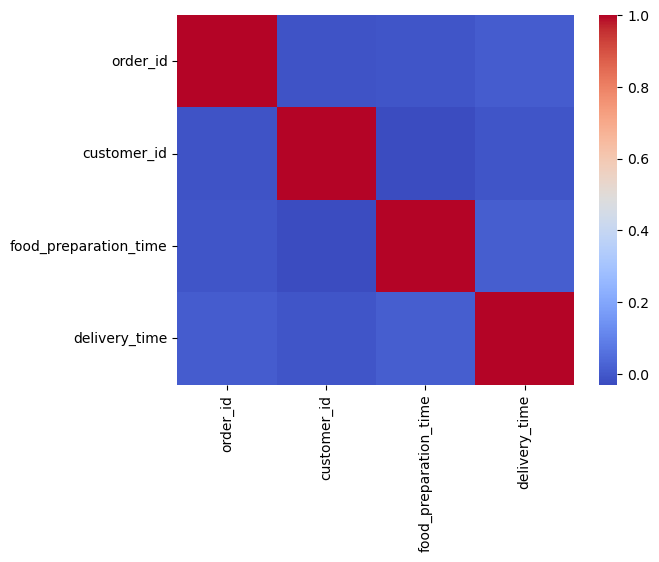

In [24]:
# Heatmap - This show the relations between numerical and categorical variables.
# There seems to be some correlations between: 
#       1. customer id and food preparations
#       2. customer id and Delivery time 
sns.heatmap(fh_df[['order_id','customer_id','food_preparation_time','delivery_time']].corr(), cmap="coolwarm");

### **Question 13:** The company wants to provide a promotional offer in the advertisement of the restaurants. The condition to get the offer is that the restaurants must have a rating count of more than 50 and the average rating should be greater than 4. Find the restaurants fulfilling the criteria to get the promotional offer. [3 marks]

The restaurants fulfilling the criteria to get the promotional offer are: Shake shack, Blue Ribbon Fried Chicken, The Meatball Shop, and Blue Ribbon Sushi.	

In [25]:
# This displays all the restaurants with the highest ratings that qualify for the promotional offer.
Promotional_offer = fh_df.groupby(['restaurant_name','rating']).value_counts().reset_index(name='Promotional_count')
Promotional_offer

,restaurant_name,rating,order_id,customer_id,cuisine_type,cost_of_the_order,day_of_the_week,food_preparation_time,delivery_time,Promotional_count
0,'wichcraft,5,1478304,321492,American,8.10,Weekday,28,28,1
1,12 Chairs,4,1477681,225912,Middle Eastern,16.30,Weekday,27,26,1
2,12 Chairs,5,1477848,276192,Middle Eastern,29.05,Weekday,28,32,1
3,12 Chairs,Not given,1476757,115610,Middle Eastern,14.12,Weekend,31,27,1
4,12 Chairs,Not given,1477960,375098,Middle Eastern,29.10,Weekend,22,26,1
...,...,...,...,...,...,...,...,...,...,...
1893,ilili Restaurant,Not given,1478224,74048,Middle Eastern,9.56,Weekend,27,27,1
1894,indikitch,4,1477984,353676,Indian,14.07,Weekend,20,30,1
1895,indikitch,5,1477901,353676,Indian,9.26,Weekend,33,26,1
1896,indikitch,Not given,1476875,373353,Indian,22.26,Weekend,35,16,1


In [26]:
# This code removes all ratings that are Not given.
p_offer = Promotional_offer[Promotional_offer['rating']!="Not given"]
p_offer

,restaurant_name,rating,order_id,customer_id,cuisine_type,cost_of_the_order,day_of_the_week,food_preparation_time,delivery_time,Promotional_count
0,'wichcraft,5,1478304,321492,American,8.10,Weekday,28,28,1
1,12 Chairs,4,1477681,225912,Middle Eastern,16.30,Weekday,27,26,1
2,12 Chairs,5,1477848,276192,Middle Eastern,29.05,Weekday,28,32,1
5,5 Napkin Burger,3,1477588,286386,American,29.05,Weekend,26,21,1
6,5 Napkin Burger,5,1478254,239985,American,25.22,Weekend,27,21,1
...,...,...,...,...,...,...,...,...,...,...
1886,ilili Restaurant,5,1477191,93797,Middle Eastern,25.22,Weekday,25,33,1
1887,ilili Restaurant,5,1477771,232035,Middle Eastern,12.23,Weekday,24,32,1
1888,ilili Restaurant,5,1477989,102801,Middle Eastern,13.73,Weekday,22,33,1
1894,indikitch,4,1477984,353676,Indian,14.07,Weekend,20,30,1


In [27]:
# This code finds all the restaurants that have a rating above 50.
po = p_offer.groupby(['restaurant_name'])['rating'].count().sort_values(ascending = False).reset_index()
po.head()

,restaurant_name,rating
0,Shake Shack,133
1,The Meatball Shop,84
2,Blue Ribbon Sushi,73
3,Blue Ribbon Fried Chicken,64
4,RedFarm Broadway,41


In [28]:
# This code finds all the restaurants that have a rating above 4.
po_four = po[po['rating'] > 4].sort_values(by='restaurant_name', ascending=False).reset_index(drop=True)
po_four

,restaurant_name,rating
0,ilili Restaurant,13
1,Yama Japanese Restaurant,8
2,Xi'an Famous Foods,7
3,Westville Hudson,9
4,Vanessa's Dumplings,6
5,Vanessa's Dumpling House,5
6,The Smile,12
7,The Meatball Shop,84
8,The Kati Roll Company,10
9,Tamarind TriBeCa,20


### **Question 14:** The company charges the restaurant 25% on the orders having cost greater than 20 dollars and 15% on the orders having cost greater than 5 dollars. Find the net revenue generated by the company across all orders. [3 marks]

The net revenue generated by the company across all orders is $62,586.90.

In [29]:
# Write the code here
cost_greater_20 = fh_df.loc[fh_df['cost_of_the_order']>20]
cost_greater_20.sum()


order_id                                                         820026389
customer_id                                                       94823444
restaurant_name          HangawiBlue Ribbon Fried ChickenTamarind TriBe...
cuisine_type             KoreanAmericanIndianAmericanJapaneseAmericanAm...
cost_of_the_order                                                 14754.91
day_of_the_week          WeekendWeekendWeekdayWeekendWeekendWeekendWeek...
rating                   Not given335Not given455555545Not given555Not ...
food_preparation_time                                                15298
delivery_time                                                        13326
dtype: object

In [30]:
# Write the code here
fh_df.loc[fh_df['cost_of_the_order']>5].sum() + fh_df.loc[fh_df['cost_of_the_order']<20].sum()

order_id                                                        4775248745
customer_id                                                      553526402
restaurant_name          HangawiBlue Ribbon Sushi IzakayaCafe HabanaBlu...
cuisine_type             KoreanJapaneseMexicanAmericanAmericanIndianIta...
cost_of_the_order                                                 47831.99
day_of_the_week          WeekendWeekendWeekdayWeekendWeekdayWeekdayWeek...
rating                   Not givenNot given5343Not given355Not given553...
food_preparation_time                                                88364
delivery_time                                                        78174
dtype: object

In [31]:
fh_df.loc[fh_df['cost_of_the_order']>20].sum()+fh_df.loc[fh_df['cost_of_the_order']>5].sum() + fh_df.loc[fh_df['cost_of_the_order']<20].sum()

order_id                                                        5595275134
customer_id                                                      648349846
restaurant_name          HangawiBlue Ribbon Fried ChickenTamarind TriBe...
cuisine_type             KoreanAmericanIndianAmericanJapaneseAmericanAm...
cost_of_the_order                                                  62586.9
day_of_the_week          WeekendWeekendWeekdayWeekendWeekendWeekendWeek...
rating                   Not given335Not given455555545Not given555Not ...
food_preparation_time                                               103662
delivery_time                                                        91500
dtype: object

### **Question 15:** The company wants to analyze the total time required to deliver the food. What percentage of orders take more than 60 minutes to get delivered from the time the order is placed? (The food has to be prepared and then delivered.) [2 marks]

10.53% of orders take more than 60 minutes to get delivered from the time the order is placed.

In [32]:
percent_time = fh_df['delivery_time']+fh_df['food_preparation_time']
percent_time

0       45
1       48
2       51
3       40
4       49
        ..
1893    48
1894    50
1895    55
1896    54
1897    52
Length: 1898, dtype: int64

In [33]:
(((percent_time>60).value_counts())/1898)*100

False    89.462592
True     10.537408
Name: count, dtype: float64

### **Question 16:** The company wants to analyze the delivery time of the orders on weekdays and weekends. How does the mean delivery time vary during weekdays and weekends? [2 marks]

The mean delivery time varies during by 5.87 minutes more on the weekdays than on the weekends.

In [34]:
Delivery_Mean_time = fh_df.groupby(['day_of_the_week'])['delivery_time'].mean()
Delivery_Mean_time


day_of_the_week
Weekday    28.340037
Weekend    22.470022
Name: delivery_time, dtype: float64

### Conclusion and Recommendations

### **Question 17:** What are your conclusions from the analysis? What recommendations would you like to share to help improve the business? (You can use cuisine type and feedback ratings to drive your business recommendations.) [6 marks]

In [35]:
Top_count = fh_df.groupby(['cuisine_type'])['order_id'].count().reset_index()
Top_count

,cuisine_type,order_id
0,American,584
1,Chinese,215
2,French,18
3,Indian,73
4,Italian,298
5,Japanese,470
6,Korean,13
7,Mediterranean,46
8,Mexican,77
9,Middle Eastern,49


In [36]:
Top_delivery_time = fh_df.groupby(['cuisine_type', 'delivery_time'])['order_id'].count().reset_index().min()
Top_delivery_time 

cuisine_type     American
delivery_time          15
order_id                1
dtype: object

Conclusion:
* The most popular cuisines are American with 584 orders, Japanese with 470 orders, Italian with 298 orders,
  Chinese with 215 orders and Mexican with 77 orders.
* The top 5 restauants are Shake Shack, Blue Ribbon Fried Chicken, Blue Ribbon Sushi, The Meatball Shop and Parm.
* Minimum time is 15 minutes for delivery and 20 minutes for Food preparation.
* Maximum time is 33 minutes for delivery and 35 minutes for Food preparation.
        

Recommendations to increase revenue:
* Foodhub should concentrate on the most cuisines. 
* Foodhub may want to work with the restauants that are not outliers according to the Boxplot chart. 
  Perhaps stay within the Q1 to Q3 restauants. To maximize revenue Foodhub may want to focus on the top 5 to 10 restauants. 
* Foodhub could work with restauants to decrease the food delivery. Perhaps incorporating a feature that helps the deliervers  
  be more just-in-time. 
* Foodhub could work with restauants to reduce food preparation times.
* Foodhub may want to consider an incentive to get better review data. Out of 1898 responses they have 736 orders that are  
  not rated. This is about 38.77 percent of the total orders. If this could be reduced by 10% to 20 % this would increase revenue significantly.

---